<a href="https://colab.research.google.com/github/Alarmelmangai-K/master-thesis/blob/main/Clinivar_mutations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving filtered_mutations.csv to filtered_mutations.csv


In [ ]:
import pandas as pd
csv_path = next(iter(uploaded.keys()))
df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", df.shape)
df.head(3)


Loaded: filtered_mutations.csv
Shape: (33645, 43)


,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,24356,Deletion,NM_000059.4(BRCA2):c.7004_7007+2del,675,BRCA2,HGNC:1101,Pathogenic,1,"Jun 30, 2022",397507890,...,C,-,-,-,-,-,-,SCV000759183|SCV002668132,-,-
1,24356,Deletion,NM_000059.4(BRCA2):c.7004_7007+2del,675,BRCA2,HGNC:1101,Pathogenic,1,"Jun 30, 2022",397507890,...,C,-,-,-,-,-,-,SCV000759183|SCV002668132,-,-
2,24357,Deletion,NM_000059.4(BRCA2):c.6275_6276del (p.Leu2092fs),675,BRCA2,HGNC:1101,Pathogenic,1,"Apr 22, 2016",11571658,...,C,-,-,-,-,-,-,SCV000282422,-,-


In [ ]:
import numpy as np
import re

df.columns = [c.strip() for c in df.columns]

def find_col(candidates):
    cand_lower = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name.lower() in cand_lower:
            return cand_lower[name.lower()]
    return None

assembly_col = find_col(["Assembly", "GenomeAssembly", "Genome_Assembly"])
clin_sig_col = find_col(["ClinicalSignificance", "Clinical_Significance", "ClinSig"])

if assembly_col is None:
    raise ValueError("Assembly column not found. Columns:\n" + "\n".join(df.columns))
if clin_sig_col is None:
    raise ValueError("ClinicalSignificance column not found. Columns:\n" + "\n".join(df.columns))

print("Assembly col:", assembly_col)
print("ClinicalSignificance col:", clin_sig_col)


Assembly col: Assembly
ClinicalSignificance col: ClinicalSignificance


In [ ]:
df = df[df[assembly_col].astype(str).str.upper().str.contains("GRCH38", na=False)].copy()
print("After GRCh38 filter:", df.shape)

key_cols = [c for c in ["GeneSymbol", "Chromosome", "Start", "Stop", "ReferenceAllele", "AlternateAllele"] if c in df.columns]
if len(key_cols) >= 4:
    df["__variant_key__"] = df[key_cols].astype(str).agg("|".join, axis=1)
    before = df.shape[0]
    df = df.drop_duplicates("__variant_key__").copy()
    print(f"Deduplicated by {key_cols}: {before} -> {df.shape[0]}")
else:
    print("Warning: Not enough key columns found for de-duplication:", key_cols)


After GRCh38 filter: (16672, 43)
Deduplicated by ['GeneSymbol', 'Chromosome', 'Start', 'Stop', 'ReferenceAllele', 'AlternateAllele']: 16672 -> 12136


In [ ]:
def normalize_terms(s: str):
    if pd.isna(s):
        return []
    s = str(s).lower()
    parts = re.split(r"[;/|,]+", s)
    parts = [re.sub(r"\s+", " ", p.strip()) for p in parts if p.strip()]
    return parts
PATH_TERMS = {"pathogenic", "likely pathogenic", "pathogenic/likely pathogenic", "likely pathogenic/pathogenic"}
BENIGN_TERMS = {"benign", "likely benign", "benign/likely benign", "likely benign/benign"}
EXCLUDE_SUBSTRINGS = ["uncertain", "vus", "conflicting", "not provided", "other", "risk factor",
                      "association", "drug response", "protective", "affects", "-"]
def map_label(clin_sig):
    terms = normalize_terms(clin_sig)
    if not terms:
        return np.nan
    joined = " | ".join(terms)
    has_path = any(t in PATH_TERMS for t in terms) or ("pathogenic" in joined and "benign" not in joined)
    has_ben  = any(t in BENIGN_TERMS for t in terms) or ("benign" in joined and "pathogenic" not in joined)
    if any(x in joined for x in EXCLUDE_SUBSTRINGS):
        pass
    if has_path and not has_ben:
        if any(x in joined for x in ["conflicting", "uncertain", "vus", "not provided"]):
            return np.nan
        return 1
    if has_ben and not has_path:
        if any(x in joined for x in ["conflicting", "uncertain", "vus", "not provided"]):
            return np.nan
        return 0
    return np.nan
df["y_pathogenic"] = df[clin_sig_col].apply(map_label)
before = df.shape[0]
df = df.dropna(subset=["y_pathogenic"]).copy()
df["y_pathogenic"] = df["y_pathogenic"].astype(int)

print(f"After label filter: {before} -> {df.shape[0]}")
print(df["y_pathogenic"].value_counts())


After label filter: 12136 -> 8403
y_pathogenic
1    5336
0    3067
Name: count, dtype: int64


In [ ]:
leakage_like = {
    "ReviewStatus", "NumberSubmitters", "Guidelines", "LastEvaluated", "ClinSigSimple",
    "AssertionCriteria", "ClinicalSignificance", "Clinical_Significance", "ClinSig",
    "RCVaccession", "SCVaccession", "VariationID", "AlleleID", "ClinVarAccession",
    "CLNHGVS", "HGVS", "HGVS_c", "HGVS_p", "ProteinChange",
    "__variant_key__"
}

cols_lower = {c.lower(): c for c in df.columns}
to_drop = []
for c in leakage_like:
    if c.lower() in cols_lower:
        to_drop.append(cols_lower[c.lower()])

for c in df.columns:
    cl = c.lower()
    if any(p in cl for p in ["accession", "variationid", "alleleid", "rcv", "scv", "clinvar"]):
        to_drop.append(c)

to_drop = sorted(set([c for c in to_drop if c != "y_pathogenic"]))
print("Dropping:", to_drop)

df_clean = df.drop(columns=to_drop, errors="ignore").copy()
print("Cleaned shape:", df_clean.shape)
df_clean.head(3)


Dropping: ['#AlleleID', 'ChromosomeAccession', 'ClinSigSimple', 'ClinicalSignificance', 'Guidelines', 'LastEvaluated', 'NumberSubmitters', 'RCVaccession', 'ReviewStatus', 'SCVsForAggregateGermlineClassification', 'SCVsForAggregateOncogenicityClassification', 'SCVsForAggregateSomaticClinicalImpact', 'VariationID']
Cleaned shape: (33645, 30)


,Type,Name,GeneID,GeneSymbol,HGNC_ID,RS# (dbSNP),nsv/esv (dbVar),PhenotypeIDS,PhenotypeList,Origin,...,SubmitterCategories,PositionVCF,ReferenceAlleleVCF,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity
0,Deletion,NM_000059.4(BRCA2):c.7004_7007+2del,675,BRCA2,HGNC:1101,397507890,-,"MONDO:MONDO:0012933,MedGen:C2675520,OMIM:61255...","Breast-ovarian cancer, familial, susceptibilit...",germline,...,3,32921028,CTTTCGG,C,-,-,-,-,-,-
1,Deletion,NM_000059.4(BRCA2):c.7004_7007+2del,675,BRCA2,HGNC:1101,397507890,-,"MONDO:MONDO:0012933,MedGen:C2675520,OMIM:61255...","Breast-ovarian cancer, familial, susceptibilit...",germline,...,3,32346891,CTTTCGG,C,-,-,-,-,-,-
2,Deletion,NM_000059.4(BRCA2):c.6275_6276del (p.Leu2092fs),675,BRCA2,HGNC:1101,11571658,-,"MONDO:MONDO:0012933,MedGen:C2675520,OMIM:61255...","Breast-ovarian cancer, familial, susceptibilit...",germline;unknown,...,3,32914766,CTT,C,-,-,-,-,-,-


In [ ]:
import numpy as np
import pandas as pd
import re
df = df_clean.copy()
drop_now = [
    "Assembly", "ReferenceAllele", "AlternateAllele", "TestedInGTR",
    "Name", "OtherIDs", "RS# (dbSNP)", "nsv/esv (dbVar)",
    "PhenotypeIDS", "PhenotypeList",
    "SomaticClinicalImpact", "SomaticClinicalImpactLastEvaluated", "ReviewStatusClinicalImpact",
    "Oncogenicity", "OncogenicityLastEvaluated", "ReviewStatusOncogenicity",
    "SubmitterCategories",
]

df = df.drop(columns=[c for c in drop_now if c in df.columns], errors="ignore")

print("After dropping risky/constant columns:", df.shape)
print("Remaining columns:", df.columns.tolist())


After dropping risky/constant columns: (8403, 14)
Remaining columns: ['Type', 'GeneID', 'GeneSymbol', 'HGNC_ID', 'Origin', 'OriginSimple', 'Chromosome', 'Start', 'Stop', 'Cytogenetic', 'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'y_pathogenic']


In [ ]:
for col in ["ReferenceAlleleVCF", "AlternateAlleleVCF"]:
    if col not in df.columns:
        raise ValueError(f"Missing expected column: {col}")

df["ref_len"] = df["ReferenceAlleleVCF"].astype(str).str.len()
df["alt_len"] = df["AlternateAlleleVCF"].astype(str).str.len()
df["len_diff"] = df["alt_len"] - df["ref_len"]
df["abs_len_diff"] = df["len_diff"].abs()

df["is_snv"] = ((df["ref_len"] == 1) & (df["alt_len"] == 1)).astype(int)
df["is_insertion"] = (df["len_diff"] > 0).astype(int)
df["is_deletion"] = (df["len_diff"] < 0).astype(int)
if "Start" in df.columns and "Stop" in df.columns:
    df["span_len"] = (df["Stop"] - df["Start"] + 1).clip(lower=1)
if "OriginSimple" in df.columns and "Origin" in df.columns:
    df = df.drop(columns=["Origin"], errors="ignore")
df = df.drop(columns=["ReferenceAlleleVCF", "AlternateAlleleVCF"], errors="ignore")

print("After feature engineering:", df.shape)
df.head(3)


After feature engineering: (8403, 19)


,Type,GeneID,GeneSymbol,HGNC_ID,OriginSimple,Chromosome,Start,Stop,Cytogenetic,PositionVCF,y_pathogenic,ref_len,alt_len,len_diff,abs_len_diff,is_snv,is_insertion,is_deletion,span_len
1,Deletion,675,BRCA2,HGNC:1101,germline,13,32346892,32346897,13q13.1,32346891,1,7,1,-6,6,0,0,1,6
3,Deletion,675,BRCA2,HGNC:1101,germline,13,32340630,32340631,13q13.1,32340629,1,3,1,-2,2,0,0,1,2
5,Deletion,675,BRCA2,HGNC:1101,germline,13,32340946,32340947,13q13.1,32340945,1,3,1,-2,2,0,0,1,2


In [ ]:
if "y_pathogenic" not in df.columns:
    raise ValueError("y_pathogenic not found.")

X = df.drop(columns=["y_pathogenic"])
y = df["y_pathogenic"].astype(int)

print("X shape:", X.shape, "y shape:", y.shape)
print("\nCategorical columns:", [c for c in X.columns if X[c].dtype == "object"])
print("Numeric columns:", [c for c in X.columns if X[c].dtype != "object"])
out_path = "/content/final_features_grch38_brca_binary.csv"
pd.concat([X, y], axis=1).to_csv(out_path, index=False)
print("Saved:", out_path)


X shape: (8403, 18) y shape: (8403,)

Categorical columns: ['Type', 'GeneSymbol', 'HGNC_ID', 'OriginSimple', 'Chromosome', 'Cytogenetic']
Numeric columns: ['GeneID', 'Start', 'Stop', 'PositionVCF', 'ref_len', 'alt_len', 'len_diff', 'abs_len_diff', 'is_snv', 'is_insertion', 'is_deletion', 'span_len']
Saved: /content/final_features_grch38_brca_binary.csv


In [ ]:
df = df.drop(columns=["Start", "Stop"], errors="ignore")
print(df.shape)


(8403, 17)


In [ ]:
import pandas as pd
X = df.drop(columns=["y_pathogenic"])
y = df["y_pathogenic"].astype(int)

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True).round(3))


X shape: (8403, 16)
y distribution:
 y_pathogenic
1    0.635
0    0.365
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols),
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (6722, 16) Test: (1681, 16)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


In [ ]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),
    "SVM_RBF": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, y_prob)
    pr  = average_precision_score(y_test, y_prob)

    results.append({
        "Model": name,
        "ROC_AUC": round(roc, 3),
        "PR_AUC": round(pr, 3)
    })

pd.DataFrame(results)


,Model,ROC_AUC,PR_AUC
0,LogisticRegression,0.701,0.826
1,RandomForest,0.896,0.939
2,XGBoost,0.913,0.956
3,SVM_RBF,0.533,0.665


In [ ]:
!pip -q install shap


In [ ]:
import numpy as np
import pandas as pd
import shap

from sklearn.pipeline import Pipeline
np.random.seed(42)


In [ ]:
pipes = {}
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pipes[name] = pipe

list(pipes.keys())


['LogisticRegression', 'RandomForest', 'XGBoost', 'SVM_RBF']

In [ ]:
preprocess.fit(X_train)

X_train_t = preprocess.transform(X_train)
X_test_t  = preprocess.transform(X_test)
def get_feature_names_from_preprocess(preprocess, num_cols, cat_cols):
    feature_names = []
    feature_names += list(num_cols)
    ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
    cat_features = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names += cat_features
    return feature_names

feature_names = get_feature_names_from_preprocess(preprocess, num_cols, cat_cols)

X_train_df = pd.DataFrame(X_train_t, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_t, columns=feature_names)

print("Transformed shapes:", X_train_df.shape, X_test_df.shape)
X_train_df.head(2)


Transformed shapes: (6722, 29) (1681, 29)


,GeneID,PositionVCF,ref_len,alt_len,len_diff,abs_len_diff,is_snv,is_insertion,is_deletion,span_len,...,HGNC_ID_HGNC:1101,OriginSimple_germline,OriginSimple_germline/somatic,OriginSimple_not applicable,OriginSimple_somatic,OriginSimple_unknown,Chromosome_13,Chromosome_17,Cytogenetic_13q13.1,Cytogenetic_17q21.31
0,675.0,32363369.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,675.0,32339657.0,2.0,1.0,-1.0,1.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:

tree_models = ["RandomForest", "XGBoost"]
tree_shap_values = {}

for name in tree_models:
    model = pipes[name].named_steps["model"]
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_test_df)
    if isinstance(sv, list):
        sv = sv[1]

    tree_shap_values[name] = (explainer, sv)

    print(name, "SHAP shape:", sv.shape)


RandomForest SHAP shape: (1681, 29, 2)
XGBoost SHAP shape: (1681, 29)


In [ ]:
kernel_models = ["LogisticRegression", "SVM_RBF"]
kernel_shap_values = {}
bg_size = 200
bg = X_train_df.sample(n=min(bg_size, len(X_train_df)), random_state=42)
n_explain = 100
X_explain = X_test_df.sample(n=min(n_explain, len(X_test_df)), random_state=42)
for name in kernel_models:
    pipe = pipes[name]
    model = pipe.named_steps["model"]
    def predict_proba_transformed(X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else X
        return model.predict_proba(X_arr)[:, 1]
    explainer = shap.KernelExplainer(predict_proba_transformed, bg)
    sv = explainer.shap_values(X_explain, nsamples=100)
    kernel_shap_values[name] = (explainer, X_explain, sv)
    print(name, "SHAP shape:", np.array(sv).shape)


  0%|          | 0/100 [00:00<?, ?it/s]

LogisticRegression SHAP shape: (100, 29)


  0%|          | 0/100 [00:00<?, ?it/s]

SVM_RBF SHAP shape: (100, 29)


/tmp/ipython-input-2812549952.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test_df, show=False, max_display=20)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


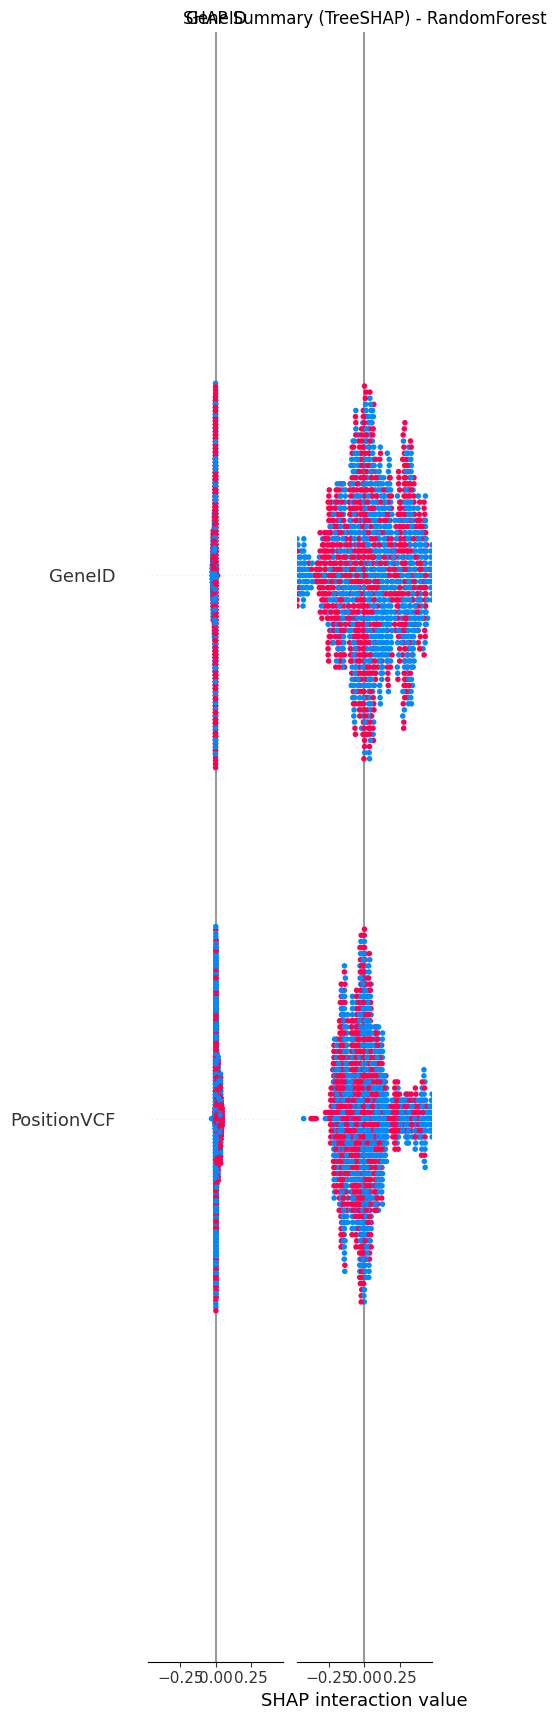

/tmp/ipython-input-2812549952.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test_df, show=False, max_display=20)


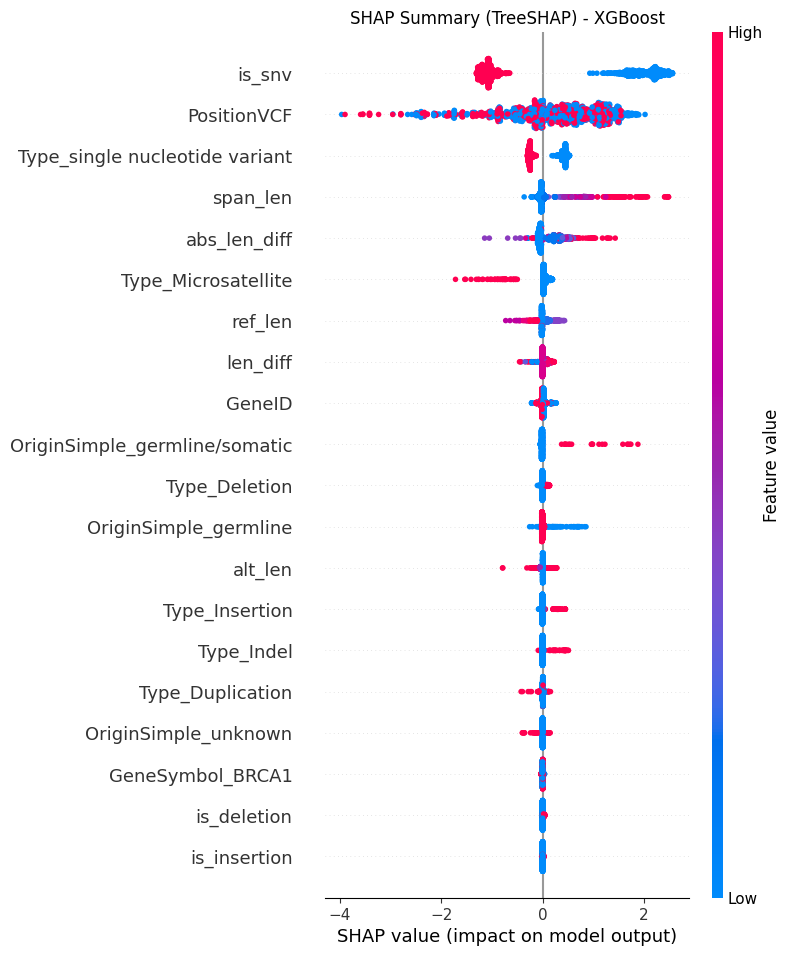

In [ ]:
import matplotlib.pyplot as plt
for name in tree_models:
    explainer, sv = tree_shap_values[name]
    shap.summary_plot(sv, X_test_df, show=False, max_display=20)
    plt.title(f"SHAP Summary (TreeSHAP) - {name}")
    plt.show()

/tmp/ipython-input-39097789.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_explain, show=False, max_display=20)


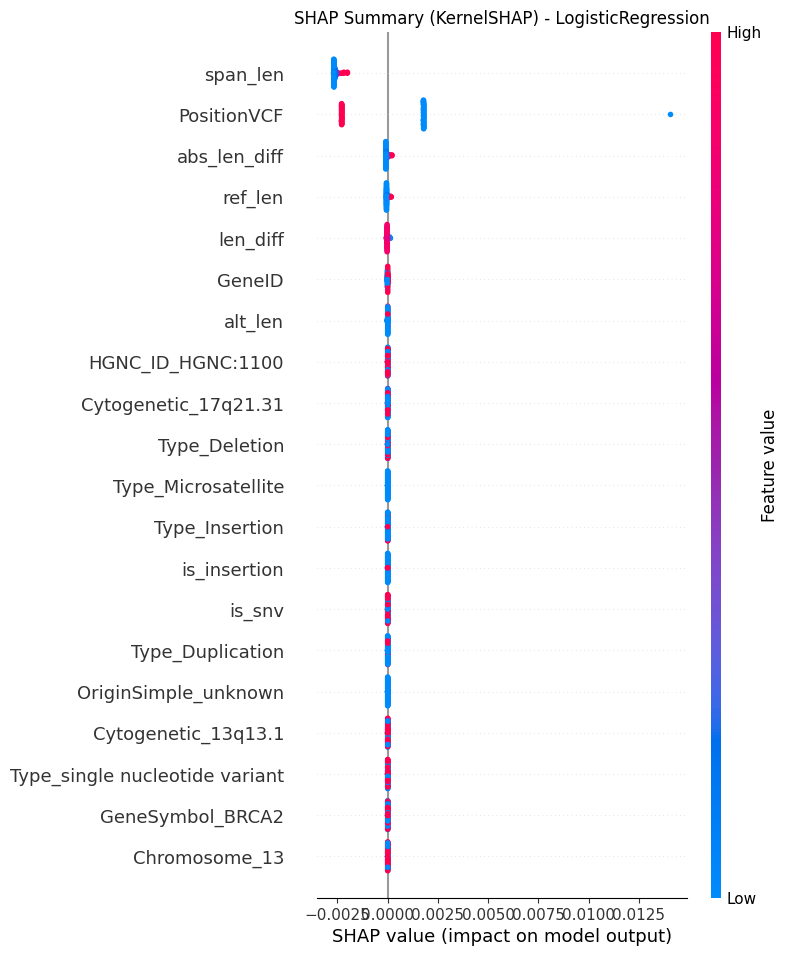

/tmp/ipython-input-39097789.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_explain, show=False, max_display=20)


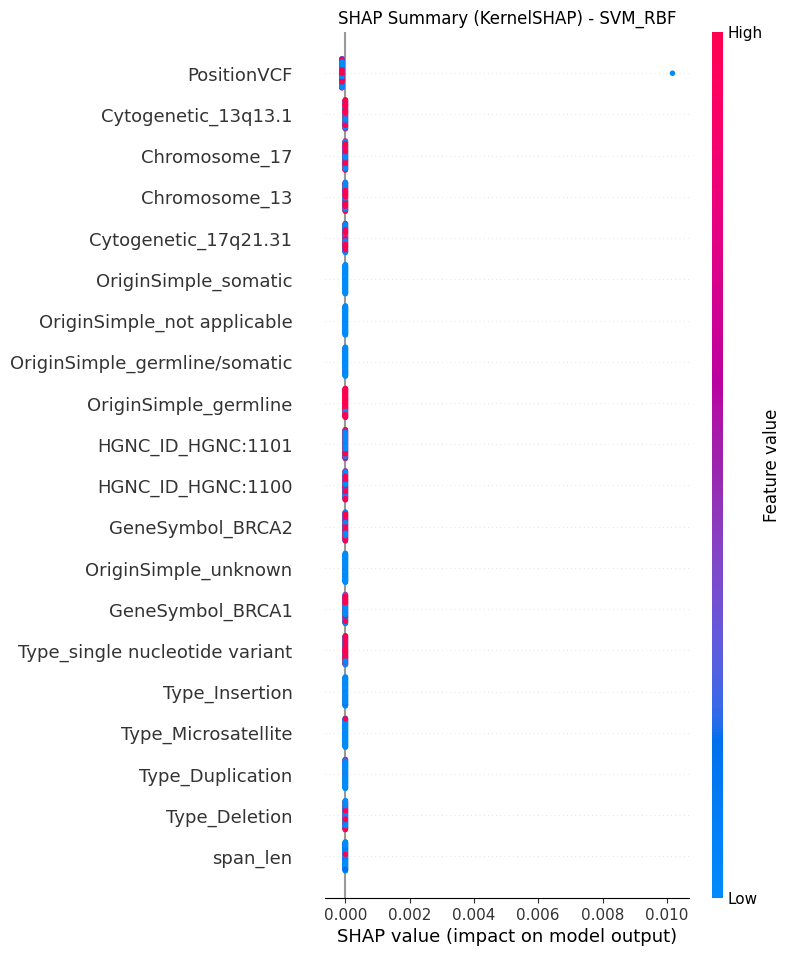

In [ ]:
import matplotlib.pyplot as plt
for name in kernel_models:
    explainer, X_explain, sv = kernel_shap_values[name]
    shap.summary_plot(sv, X_explain, show=False, max_display=20)
    plt.title(f"SHAP Summary (KernelSHAP) - {name}")
    plt.show()


In [ ]:
def top_k_from_shap(shap_values, feature_names, k=20):
        shap_values = np.array(shap_values)

    if shap_values.ndim == 3:
        mean_abs = np.abs(shap_values).mean(axis=(0, 2))
    elif shap_values.ndim == 2:
        mean_abs = np.abs(shap_values).mean(axis=0)
    else:
        raise ValueError(f"Unexpected SHAP values dimensionality: {shap_values.ndim}")

    idx = np.argsort(mean_abs)[::-1][:k]
    return pd.DataFrame({
        "feature": np.array(feature_names)[idx],
        "mean_abs_shap": mean_abs[idx]
    })
for name in tree_models:
    _, sv = tree_shap_values[name]
    top = top_k_from_shap(sv, X_test_df.columns, k=20)
    print("\nTop 20 features:", name)
    display(top)
for name in kernel_models:
    _, X_explain, sv = kernel_shap_values[name]
    top = top_k_from_shap(np.array(sv), X_explain.columns, k=20)
    print("\nTop 20 features:", name)
    display(top)



Top 20 features: RandomForest


,feature,mean_abs_shap
0,PositionVCF,0.121092
1,is_snv,0.085756
2,Type_single nucleotide variant,0.074910
3,abs_len_diff,0.047861
4,span_len,0.038860
5,ref_len,0.030538
6,is_deletion,0.022567
7,len_diff,0.018168
8,alt_len,0.015385
9,Type_Deletion,0.014921



Top 20 features: XGBoost


,feature,mean_abs_shap
0,is_snv,1.568316
1,PositionVCF,0.820476
2,Type_single nucleotide variant,0.338646
3,span_len,0.186590
4,abs_len_diff,0.184536
5,Type_Microsatellite,0.071977
6,ref_len,0.056309
7,len_diff,0.050271
8,GeneID,0.032492
9,OriginSimple_germline/somatic,0.025528



Top 20 features: LogisticRegression


,feature,mean_abs_shap
0,span_len,2.630775e-03
1,PositionVCF,2.121209e-03
2,abs_len_diff,8.420237e-05
3,ref_len,5.722725e-05
4,len_diff,3.362265e-05
5,GeneID,1.169347e-05
6,alt_len,2.356547e-06
7,HGNC_ID_HGNC:1100,3.853746e-07
8,Cytogenetic_17q21.31,3.129186e-07
9,Type_Deletion,2.978598e-07



Top 20 features: SVM_RBF


,feature,mean_abs_shap
0,PositionVCF,0.000203
1,Cytogenetic_13q13.1,0.000000
2,Chromosome_17,0.000000
3,Chromosome_13,0.000000
4,Cytogenetic_17q21.31,0.000000
5,OriginSimple_somatic,0.000000
6,OriginSimple_not applicable,0.000000
7,OriginSimple_germline/somatic,0.000000
8,OriginSimple_germline,0.000000
9,HGNC_ID_HGNC:1101,0.000000


In [ ]:
out_dir = "/content/shap_outputs"
import os
os.makedirs(out_dir, exist_ok=True)
for name in tree_models:
    _, sv = tree_shap_values[name]
    top = top_k_from_shap(sv, X_test_df.columns, k=50)
    top.to_csv(f"{out_dir}/top50_{name}_TreeSHAP.csv", index=False)
for name in kernel_models:
    _, X_explain, sv = kernel_shap_values[name]
    top = top_k_from_shap(np.array(sv), X_explain.columns, k=50)
    top.to_csv(f"{out_dir}/top50_{name}_KernelSHAP.csv", index=False)

print("Saved to:", out_dir)


Saved to: /content/shap_outputs


In [ ]:
!pip -q install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
bg = X_train_df.sample(n=min(2000, len(X_train_df)), random_state=42).values
feature_names_lime = X_train_df.columns.tolist()

explainer_lime = LimeTabularExplainer(
    training_data=bg,
    feature_names=feature_names_lime,
    class_names=["Benign", "Pathogenic"],
    mode="classification",
    discretize_continuous=True
)

def proba_from_pipe_transformed(pipe, X_transformed_df):
    model = pipe.named_steps["model"]
    X_arr = X_transformed_df.values if hasattr(X_transformed_df, "values") else X_transformed_df
    return model.predict_proba(X_arr)
chosen = "XGBoost"
pipe = pipes[chosen]

idx = 0
x_row = X_test_df.iloc[idx].values

exp = explainer_lime.explain_instance(
    data_row=x_row,
    predict_fn=lambda X: proba_from_pipe_transformed(pipe, pd.DataFrame(X, columns=feature_names_lime)),
    num_features=15
)
print("LIME explanation (top 15):")
for f, w in exp.as_list():
    print(f"{f}: {w:.4f}")


LIME explanation (top 15):
0.00 < is_snv <= 1.00: -0.3413
OriginSimple_germline/somatic <= 0.00: -0.2805
span_len <= 1.00: -0.1155
Type_Microsatellite <= 0.00: 0.1125
abs_len_diff <= 0.00: -0.0741
0.00 < Type_single nucleotide variant <= 1.00: -0.0728
Type_Indel <= 0.00: -0.0680
-1.00 < len_diff <= 0.00: 0.0617
OriginSimple_somatic <= 0.00: 0.0534
ref_len <= 1.00: 0.0515
PositionVCF > 43091998.00: 0.0370
Type_Insertion <= 0.00: -0.0298
GeneID <= 672.00: -0.0167
OriginSimple_unknown <= 0.00: 0.0129
Chromosome_13 <= 0.00: 0.0120


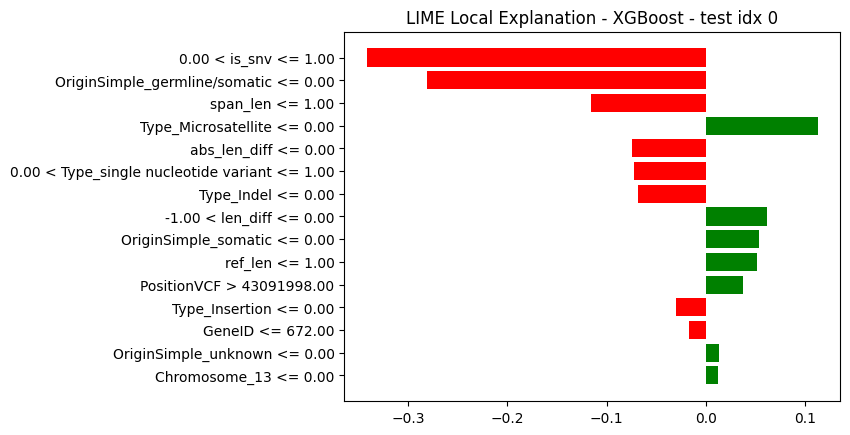

In [ ]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
plt.title(f"LIME Local Explanation - {chosen} - test idx {idx}")
plt.savefig(f"lime_local_{chosen}_idx{idx}.png")
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score
def pr_auc_scorer(estimator, X, y):
    y_pred_proba = estimator.predict_proba(X)[:, 1]
    return average_precision_score(y, y_pred_proba)

perm_results = {}

for name, pipe in pipes.items():
    r = permutation_importance(
        pipe, X_test, y_test,
        n_repeats=10,
        random_state=42,
        scoring=pr_auc_scorer,
        n_jobs=-1
    )
    perm_results[name] = r
    print(name, "Permutation importance computed.")

LogisticRegression Permutation importance computed.
RandomForest Permutation importance computed.
XGBoost Permutation importance computed.
SVM_RBF Permutation importance computed.


In [ ]:
from sklearn.base import clone

perm_transformed = {}
for name in pipes.keys():
    model = pipes[name].named_steps["model"]
    X_eval = X_test_df.copy()
    y_eval = y_test.values

    def pr_auc_model(model, X, y):
        return average_precision_score(y, model.predict_proba(X)[:, 1])
    base_score = pr_auc_model(model, X_eval.values, y_eval)

    rng = np.random.RandomState(42)
    importances = np.zeros(X_eval.shape[1])

    for j, col in enumerate(X_eval.columns):
        scores = []
        for _ in range(10):
            Xp = X_eval.values.copy()
            rng.shuffle(Xp[:, j])
            scores.append(pr_auc_model(model, Xp, y_eval))
        importances[j] = base_score - np.mean(scores)

    perm_transformed[name] = pd.Series(importances, index=X_eval.columns).sort_values(ascending=False)
    print("Permutation (transformed) done:", name)

display(perm_transformed["XGBoost"].head(20).to_frame("perm_drop_in_PR_AUC"))


Permutation (transformed) done: LogisticRegression
Permutation (transformed) done: RandomForest
Permutation (transformed) done: XGBoost
Permutation (transformed) done: SVM_RBF


,perm_drop_in_PR_AUC
is_snv,1.110959e-01
PositionVCF,3.761412e-02
OriginSimple_germline/somatic,1.036082e-03
span_len,8.746102e-04
Type_single nucleotide variant,7.364107e-04
len_diff,3.747842e-04
GeneID,3.532243e-04
OriginSimple_germline,2.288601e-04
Type_Indel,1.010131e-04
Type_Microsatellite,9.917640e-05


In [ ]:
builtin_importance = {}
if "LogisticRegression" in pipes:
    lr = pipes["LogisticRegression"].named_steps["model"]
    coef = pd.Series(lr.coef_.ravel(), index=X_train_df.columns)
    builtin_importance["LogisticRegression_coef_abs"] = coef.abs().sort_values(ascending=False)
for name in ["RandomForest", "XGBoost"]:
    if name in pipes:
        m = pipes[name].named_steps["model"]
        fi = pd.Series(m.feature_importances_, index=X_train_df.columns).sort_values(ascending=False)
        builtin_importance[f"{name}_feature_importances"] = fi

for k, v in builtin_importance.items():
    print("\nTop 15 built-in:", k)
    display(v.head(15).to_frame("importance"))



Top 15 built-in: LogisticRegression_coef_abs


,importance
span_len,2.228979e-04
abs_len_diff,9.510910e-05
ref_len,7.346845e-05
len_diff,5.106393e-05
GeneID,3.774047e-05
alt_len,2.240452e-05
is_snv,2.124260e-06
Type_single nucleotide variant,2.124260e-06
is_deletion,1.459786e-06
Type_Deletion,1.320989e-06



Top 15 built-in: RandomForest_feature_importances


,importance
PositionVCF,0.437324
is_snv,0.124470
Type_single nucleotide variant,0.106544
abs_len_diff,0.081490
span_len,0.051307
ref_len,0.044821
is_deletion,0.035820
len_diff,0.032855
Type_Deletion,0.025497
alt_len,0.020839



Top 15 built-in: XGBoost_feature_importances


,importance
Type_single nucleotide variant,0.553881
is_snv,0.384866
OriginSimple_germline/somatic,0.012287
Type_Microsatellite,0.005296
PositionVCF,0.005010
is_deletion,0.003417
abs_len_diff,0.003225
GeneSymbol_BRCA2,0.003190
ref_len,0.002876
span_len,0.002859


In [ ]:
import numpy as np
import pandas as pd
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import shap
def get_feature_names_from_preprocess(preprocess_obj, num_cols, cat_cols):
    feature_names = []
    feature_names += list(num_cols)
    ohe = preprocess_obj.named_transformers_["cat"].named_steps["onehot"]
    cat_features = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names += cat_features
    return feature_names

def mean_abs_shap_tree(model, X_df):
    expl = shap.TreeExplainer(model)
    sv = expl.shap_values(X_df, check_additivity=False)
    if isinstance(sv, list):
        sv = sv[1]
    elif isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv = sv[:, :, 1]
    return np.abs(sv).mean(axis=0)

def builtin_vector(model):
    if hasattr(model, 'feature_importances_'):
        return model.feature_importances_
    return None

def lr_coef_abs(model):
    return np.abs(model.coef_.ravel())


B = 20
n_shap = 400
rng = np.random.RandomState(42)
preprocess.fit(X_train)
fixed_feature_names = get_feature_names_from_preprocess(preprocess, num_cols, cat_cols)
idx_shap = rng.choice(len(X_test), size=min(n_shap, len(X_test)), replace=False)
X_test_small = X_test.iloc[idx_shap].copy()
X_test_small_t = preprocess.transform(X_test_small)
X_test_small_df = pd.DataFrame(X_test_small_t, columns=fixed_feature_names)

bootstrap_store = {
    "RandomForest": {"shap": [], "builtin": []},
    "XGBoost": {"shap": [], "builtin": []},
    "LogisticRegression": {"coef": []}
}
rf_base = clone(models["RandomForest"]).set_params(n_estimators=150, n_jobs=-1)
xgb_base = clone(models["XGBoost"]).set_params(n_estimators=150)

for b in range(B):
    Xb, yb = resample(
        X_train, y_train,
        replace=True,
        random_state=1000 + b,
        stratify=y_train
    )
    Xb_transformed = preprocess.transform(Xb)
    Xb_df_transformed = pd.DataFrame(Xb_transformed, columns=fixed_feature_names)
    rf = clone(rf_base).set_params(random_state=1000 + b)
    rf.fit(Xb_df_transformed, yb)

    bootstrap_store["RandomForest"]["builtin"].append(builtin_vector(rf))
    bootstrap_store["RandomForest"]["shap"].append(mean_abs_shap_tree(rf, X_test_small_df))
    xgb = clone(xgb_base).set_params(random_state=2000 + b)
    xgb.fit(Xb_df_transformed, yb)

    bootstrap_store["XGBoost"]["builtin"].append(builtin_vector(xgb))
    bootstrap_store["XGBoost"]["shap"].append(mean_abs_shap_tree(xgb, X_test_small_df))
    lr = clone(models["LogisticRegression"]).set_params(random_state=3000 + b)
    lr.fit(Xb_df_transformed, yb)

    bootstrap_store["LogisticRegression"]["coef"].append(lr_coef_abs(lr))

    if (b + 1) % 5 == 0:
        print(f"Bootstrap {b+1}/{B} done")

for m in ["RandomForest", "XGBoost"]:
    for method in ["shap", "builtin"]:
        bootstrap_store[m][method] = np.vstack(bootstrap_store[m][method])
bootstrap_store["LogisticRegression"]["coef"] = np.vstack(bootstrap_store["LogisticRegression"]["coef"])

print("RF shap:", bootstrap_store["RandomForest"]["shap"].shape)
print("XGB shap:", bootstrap_store["XGBoost"]["shap"].shape)
print("LR coef:", bootstrap_store["LogisticRegression"]["coef"].shape)

Bootstrap 5/20 done
Bootstrap 10/20 done
Bootstrap 15/20 done
Bootstrap 20/20 done
RF shap: (20, 29)
XGB shap: (20, 29)
LR coef: (20, 29)


In [ ]:
from scipy.stats import spearmanr
def topk_idx(v, k):
    return np.argsort(v)[::-1][:k]
def jaccard_topk(v1, v2, k):
    a = set(topk_idx(v1, k))
    b = set(topk_idx(v2, k))
    return len(a & b) / max(1, len(a | b))
def stability_report(V, k=10):
    B = V.shape[0]
    spears = []
    jacs = []
    for i in range(B):
        for j in range(i+1, B):
            spears.append(spearmanr(V[i], V[j]).correlation)
            jacs.append(jaccard_topk(V[i], V[j], k))
    return float(np.nanmean(spears)), float(np.nanmean(jacs))

stability_table = []

for model_name in ["RandomForest", "XGBoost"]:
    for method in ["shap", "builtin"]:
        V = bootstrap_store[model_name][method]
        sp, jc = stability_report(V, k=top_k)
        stability_table.append([model_name, method, sp, jc])
sp, jc = stability_report(bootstrap_store["LogisticRegression"]["coef"], k=top_k)
stability_table.append(["LogisticRegression", "coef_abs", sp, jc])

stability_df = pd.DataFrame(stability_table, columns=["Model", "Method", "Mean_Spearman", f"Mean_Jaccard@{top_k}"])
stability_df


,Model,Method,Mean_Spearman,Mean_Jaccard@10
0,RandomForest,shap,0.931211,0.906539
1,RandomForest,builtin,0.964029,0.965550
2,XGBoost,shap,0.952444,0.740191
3,XGBoost,builtin,0.895055,0.693678
4,LogisticRegression,coef_abs,0.961134,1.000000


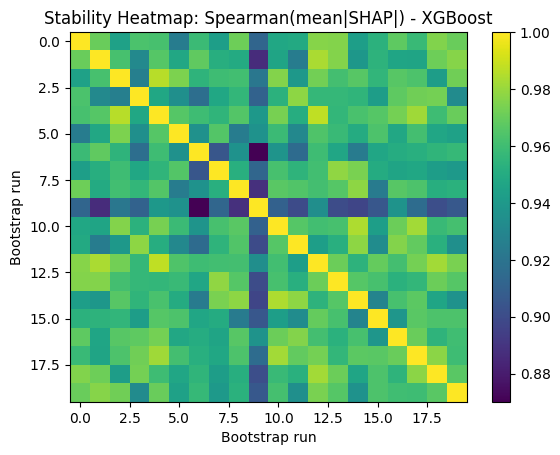

In [ ]:
import matplotlib.pyplot as plt

def stability_heatmap(V, title, fname):
    B = V.shape[0]
    corr = np.zeros((B, B))
    for i in range(B):
        for j in range(B):
            corr[i, j] = spearmanr(V[i], V[j]).correlation
    plt.figure()
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Bootstrap run")
    plt.ylabel("Bootstrap run")
    plt.show()

stability_heatmap(bootstrap_store["XGBoost"]["shap"],
                  "Stability Heatmap: Spearman(mean|SHAP|) - XGBoost",
                  "stab_heatmap_xgb_shap")


In [ ]:
def FSI(mean_spearman, mean_jaccard, w_spear=0.6, w_jacc=0.4):
    # Spearman ranges [-1,1] -> map to [0,1]
    spear01 = (mean_spearman + 1) / 2
    jacc01 = mean_jaccard  # already [0,1]
    return w_spear * spear01 + w_jacc * jacc01

stability_df["FSI"] = stability_df.apply(lambda r: FSI(r["Mean_Spearman"], r[f"Mean_Jaccard@{top_k}"]), axis=1)
stability_df.sort_values("FSI", ascending=False)


,Model,Method,Mean_Spearman,Mean_Jaccard@10,FSI
4,LogisticRegression,coef_abs,0.961134,1.000000,0.988340
1,RandomForest,builtin,0.964029,0.965550,0.975429
0,RandomForest,shap,0.931211,0.906539,0.941979
2,XGBoost,shap,0.952444,0.740191,0.881810
3,XGBoost,builtin,0.895055,0.693678,0.845988


In [ ]:
out_path = "/content/stability_fsi_table.csv"
stability_df.to_csv(out_path, index=False)
out_path


'/content/stability_fsi_table.csv'

In [ ]:
def normalize_vector(v):
    v = np.array(v, dtype=float)
    v = np.abs(v)
    s = v.sum()
    return v / s if s > 0 else v

# XGBoost vectors:
xgb_shap = np.abs(tree_shap_values["XGBoost"][1]).mean(axis=0)           # mean|SHAP|
xgb_builtin = builtin_importance["XGBoost_feature_importances"].values    # built-in
xgb_perm = perm_transformed["XGBoost"].reindex(X_test_df.columns).fillna(0).values  # perm drop in PR-AUC

methods = {
    "SHAP": normalize_vector(xgb_shap),
    "BuiltIn": normalize_vector(xgb_builtin),
    "Permutation": normalize_vector(xgb_perm),
}

# Pairwise Spearman + Jaccard
names = list(methods.keys())
S = np.zeros((len(names), len(names)))
J = np.zeros((len(names), len(names)))

for i, a in enumerate(names):
    for j, b in enumerate(names):
        S[i, j] = spearmanr(methods[a], methods[b]).correlation
        J[i, j] = jaccard_topk(methods[a], methods[b], top_k)

print("Spearman matrix:\n", pd.DataFrame(S, index=names, columns=names).round(3))
print(f"\nJaccard@{top_k} matrix:\n", pd.DataFrame(J, index=names, columns=names).round(3))


Spearman matrix:
               SHAP  BuiltIn  Permutation
SHAP         1.000    0.690        0.934
BuiltIn      0.690    1.000        0.563
Permutation  0.934    0.563        1.000

Jaccard@10 matrix:
               SHAP  BuiltIn  Permutation
SHAP         1.000    0.538        0.818
BuiltIn      0.538    1.000        0.538
Permutation  0.818    0.538        1.000


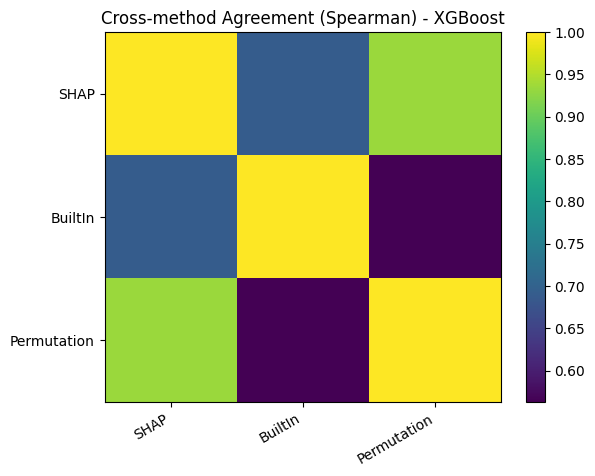

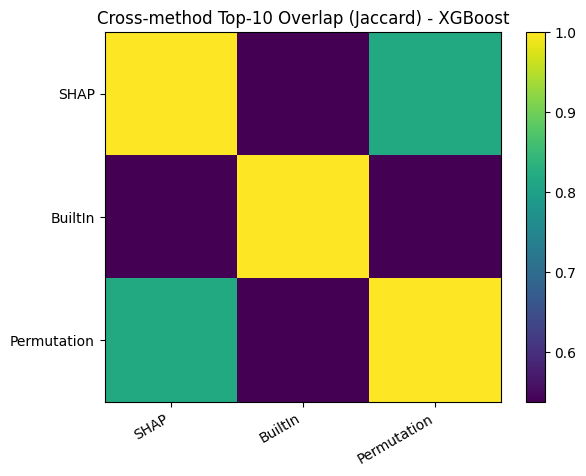

In [ ]:
import matplotlib.pyplot as plt

def matrix_plot(M, labels, title, fname):
    plt.figure()
    plt.imshow(M, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.title(title)
    plt.show()

matrix_plot(S, names, "Cross-method Agreement (Spearman) - XGBoost", "cross_method_spearman_xgb")
matrix_plot(J, names, f"Cross-method Top-{top_k} Overlap (Jaccard) - XGBoost", f"cross_method_jaccard_top{top_k}_xgb")


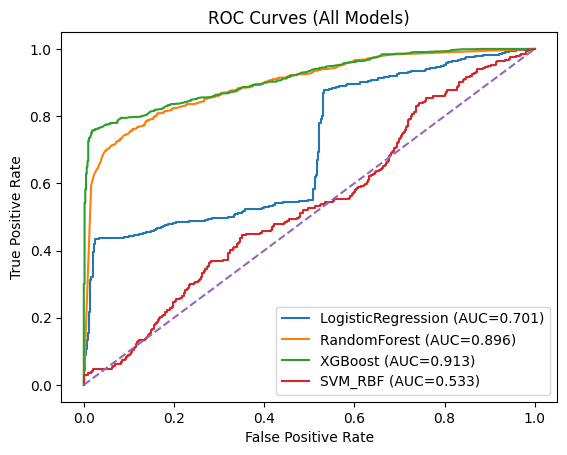

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure()
for name, pipe in pipes.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (All Models)")
plt.legend()
plt.show()


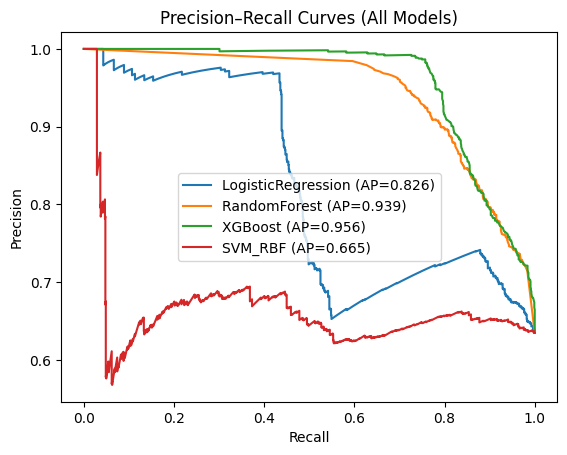

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure()
for name, pipe in pipes.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    p, r, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(r, p, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (All Models)")
plt.legend()
plt.show()


/tmp/ipython-input-920104783.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_xgb, X_test_df, max_display=20)


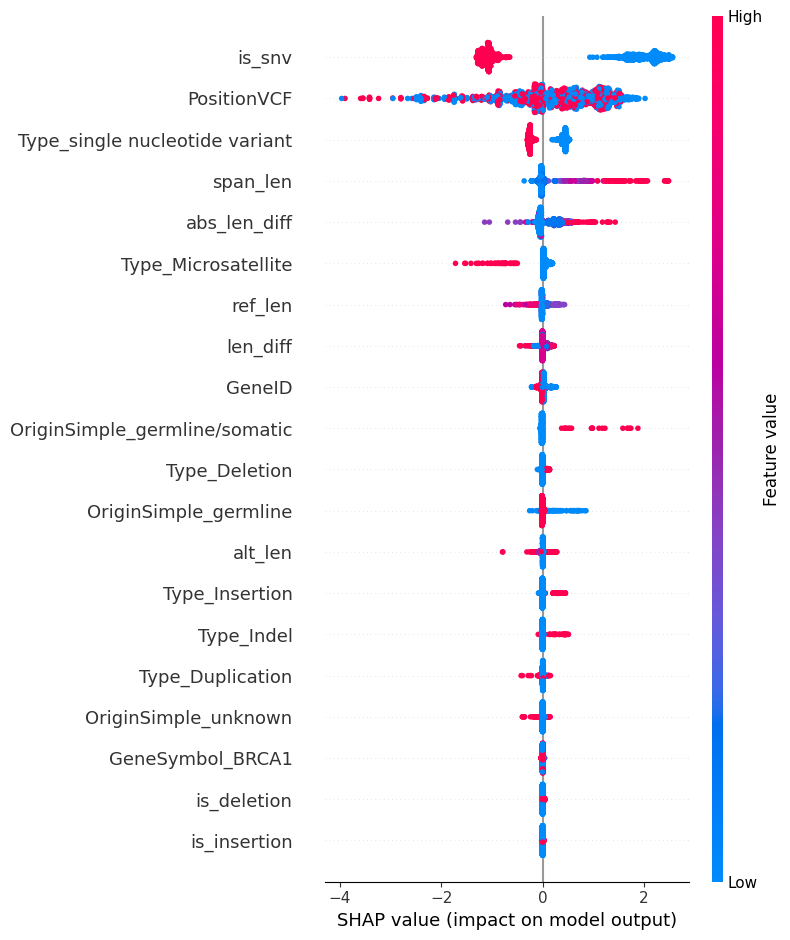

In [ ]:
import shap
import numpy as np

_, sv_xgb = tree_shap_values["XGBoost"]
if isinstance(sv_xgb, np.ndarray) and sv_xgb.ndim == 3:
    sv_xgb = sv_xgb[:, :, 1]

shap.summary_plot(sv_xgb, X_test_df, max_display=20)


Top SHAP feature: is_snv


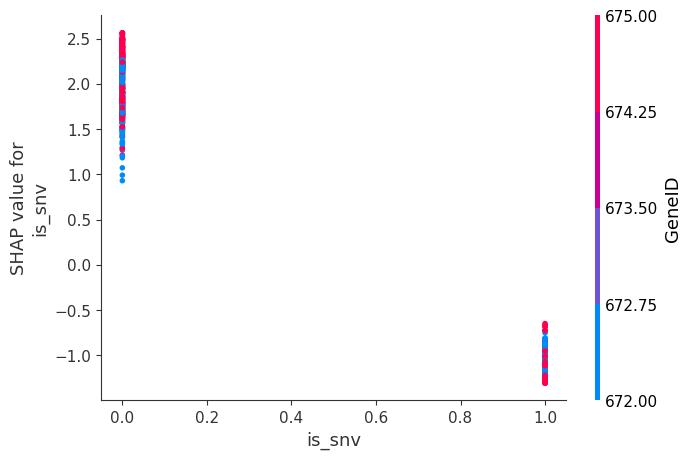

In [ ]:
mean_abs = np.abs(sv_xgb).mean(axis=0)
top_feature = X_test_df.columns[int(np.argmax(mean_abs))]
print("Top SHAP feature:", top_feature)

shap.dependence_plot(top_feature, sv_xgb, X_test_df)


TP index: 1 Predicted prob: 0.9961144


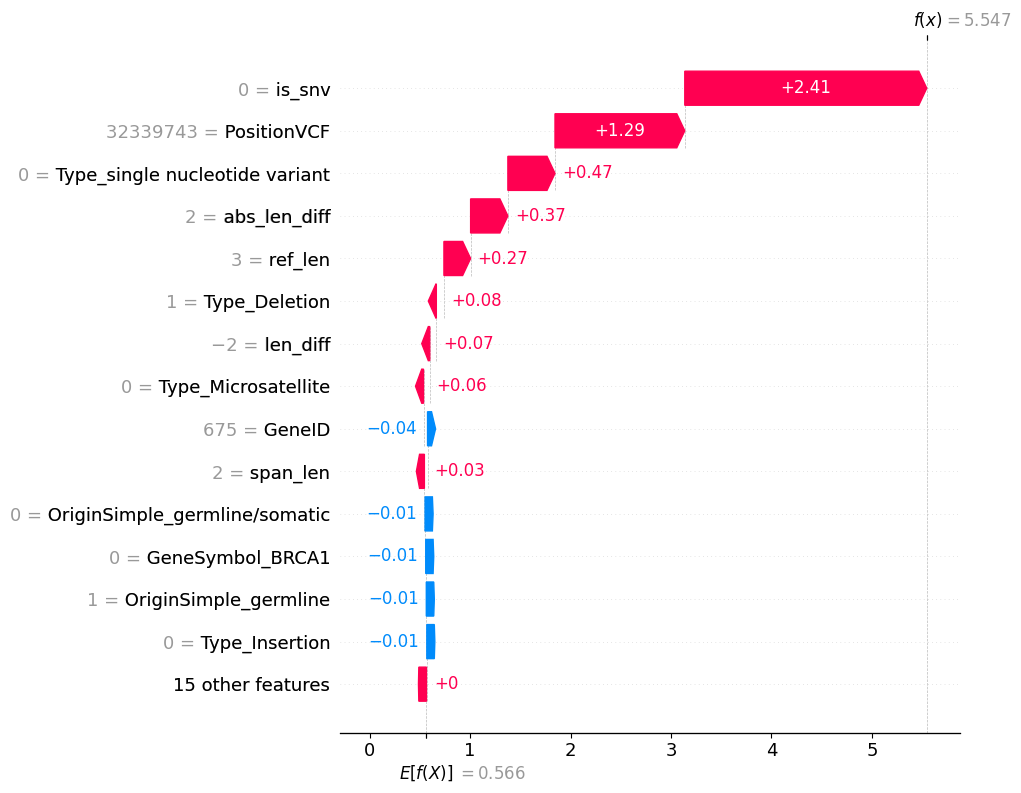

In [ ]:
explainer_xgb = tree_shap_values["XGBoost"][0]
exp = explainer_xgb(X_test_df)

xgb_model = pipes["XGBoost"].named_steps["model"]
y_prob = xgb_model.predict_proba(X_test_df.values)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

tp_idx = np.where((y_test.values == 1) & (y_pred == 1))[0][0]
print("TP index:", tp_idx, "Predicted prob:", y_prob[tp_idx])

shap.plots.waterfall(exp[tp_idx], max_display=15)


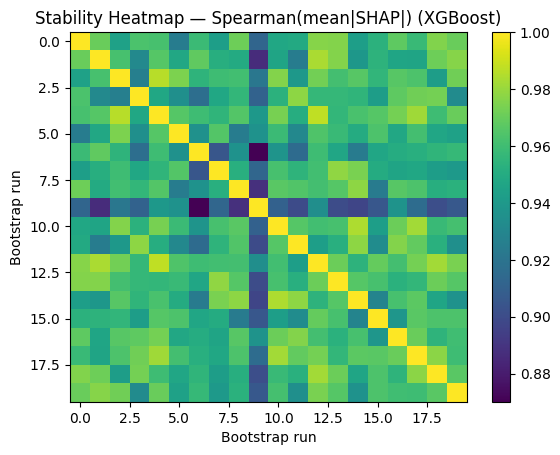

In [ ]:
from scipy.stats import spearmanr

V = bootstrap_store["XGBoost"]["shap"]  # (B, n_features)
B = V.shape[0]

corr = np.zeros((B, B))
for i in range(B):
    for j in range(B):
        corr[i, j] = spearmanr(V[i], V[j]).correlation

plt.figure()
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xlabel("Bootstrap run")
plt.ylabel("Bootstrap run")
plt.title("Stability Heatmap — Spearman(mean|SHAP|) (XGBoost)")
plt.show()


,Model,Method,Mean_Spearman,Mean_Jaccard@10,FSI
4,LogisticRegression,coef_abs,0.961134,1.000000,0.988340
1,RandomForest,builtin,0.964029,0.965550,0.975429
0,RandomForest,shap,0.931211,0.906539,0.941979
2,XGBoost,shap,0.952444,0.740191,0.881810
3,XGBoost,builtin,0.895055,0.693678,0.845988


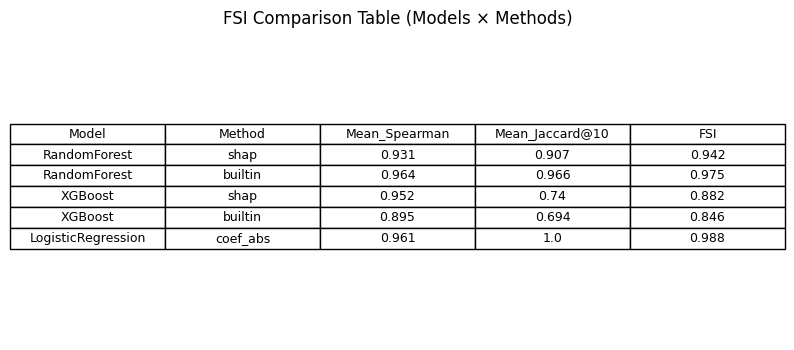

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

display(stability_df.sort_values("FSI", ascending=False))

plt.figure(figsize=(10, 4))
plt.axis("off")
tbl = plt.table(
    cellText=stability_df.round(3).values,
    colLabels=stability_df.columns.tolist(),
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.25)
plt.title("FSI Comparison Table (Models × Methods)")
plt.show()


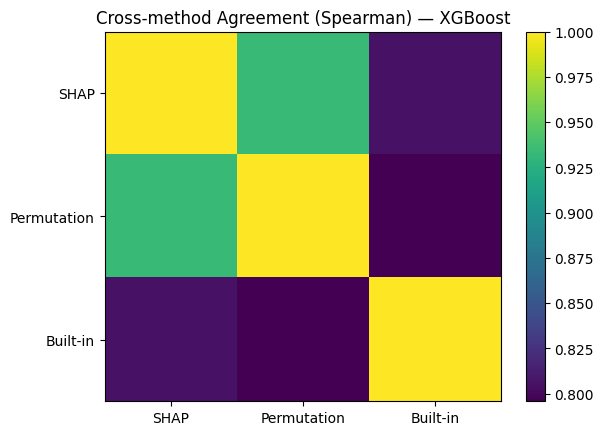

In [ ]:
from scipy.stats import spearmanr

def normalize(v):
    v = np.abs(np.array(v))
    return v / v.sum() if v.sum() > 0 else v

v_shap = normalize(np.abs(sv_xgb).mean(axis=0))
v_builtin = normalize(
    builtin_importance["XGBoost_feature_importances"]
    .reindex(X_test_df.columns)
    .fillna(0)
    .values
)
v_perm = normalize(
    perm_transformed["XGBoost"]
    .reindex(X_test_df.columns)
    .fillna(0)
    .values
)

labels = ["SHAP", "Permutation", "Built-in"]
vectors = [v_shap, v_perm, v_builtin]

M = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        M[i, j] = spearmanr(vectors[i], vectors[j]).correlation

plt.figure()
plt.imshow(M, aspect="auto")
plt.colorbar()
plt.xticks(range(3), labels)
plt.yticks(range(3), labels)
plt.title("Cross-method Agreement (Spearman) — XGBoost")
plt.show()
